# 01 — Exploratory Data Analysis
**VehicleTrajectNet** | Saturday 1

Goals:
1. Load nuScenes mini dataset
2. Run `extract_trajectories()` to build `data/trajectories.parquet`
3. Visualise raw vehicle tracks on a map tile
4. Understand the data distribution (sequence lengths, speeds, categories)

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path

# nuScenes devkit
from nuscenes.nuscenes import NuScenes
from nuscenes.map_expansion.map_api import NuScenesMap

print('Imports OK')

Imports OK


## 1 — Load nuScenes

In [2]:
# Adjust DATAROOT to wherever you placed the v1.0-mini folder
DATAROOT = '../data/nuscenes'
VERSION  = 'v1.0-mini'

nusc = NuScenes(version='v1.0-mini', dataroot=DATAROOT, verbose=True)

print(f'\nScenes  : {len(nusc.scene)}')
print(f'Samples : {len(nusc.sample)}')

Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.489 seconds.
Reverse indexing ...
Done reverse indexing in 0.1 seconds.

Scenes  : 10
Samples : 404


## 2 — Inspect one scene

In [3]:
scene = nusc.scene[0]
print('Scene name   :', scene['name'])
print('Description  :', scene['description'])
print('Num samples  :', scene['nbr_samples'])

# Walk the sample chain and print first annotation per sample
sample_token = scene['first_sample_token']
step = 0
while sample_token and step < 5:
    sample = nusc.get('sample', sample_token)
    print(f'  Step {step}: {len(sample["anns"])} annotations')
    sample_token = sample['next']
    step += 1

Scene name   : scene-0061
Description  : Parked truck, construction, intersection, turn left, following a van
Num samples  : 39
  Step 0: 69 annotations
  Step 1: 78 annotations
  Step 2: 86 annotations
  Step 3: 94 annotations
  Step 4: 103 annotations


## 3 — Extract all trajectories to parquet
This may take 30–60 seconds on nuScenes mini.

In [4]:
from dataset import extract_trajectories

df = extract_trajectories(nusc, output_path='../data/trajectories.parquet')
df.head()

Saved 30,576 rows (2,184 windows) -> ../data/trajectories.parquet


,scene_token,instance_token,window_id,step,x,y,heading,velocity,is_past
0,cc8c0bf57f984915a77078b10eb33198,bd26c2cdb22d4bb1834e808c89128898,0,0,353.794,1132.355,-0.403398,0.039404,True
1,cc8c0bf57f984915a77078b10eb33198,bd26c2cdb22d4bb1834e808c89128898,0,1,353.776,1132.363,-0.403398,0.036262,True
2,cc8c0bf57f984915a77078b10eb33198,bd26c2cdb22d4bb1834e808c89128898,0,2,353.759,1132.370,-0.403398,0.036283,True
3,cc8c0bf57f984915a77078b10eb33198,bd26c2cdb22d4bb1834e808c89128898,0,3,353.741,1132.378,-0.403398,0.038088,True
4,cc8c0bf57f984915a77078b10eb33198,bd26c2cdb22d4bb1834e808c89128898,0,4,353.724,1132.385,-0.403398,0.015945,True


## 4 — Dataset statistics

In [5]:
# How many unique trajectory windows do we have?
windows = df.groupby(['scene_token', 'instance_token', 'window_id'])
print(f'Total trajectory windows : {windows.ngroups}')
print(f'Scenes in dataset        : {df["scene_token"].nunique()}')
print(f'Unique agents            : {df["instance_token"].nunique()}')
print(f'\nSpeed stats (m/s):')
print(df['velocity'].describe().round(3))

Total trajectory windows : 2184
Scenes in dataset        : 10
Unique agents            : 149

Speed stats (m/s):
count    30576.000
mean         3.393
std          4.758
min          0.000
25%          0.051
50%          0.192
75%          6.336
max         18.498
Name: velocity, dtype: float64


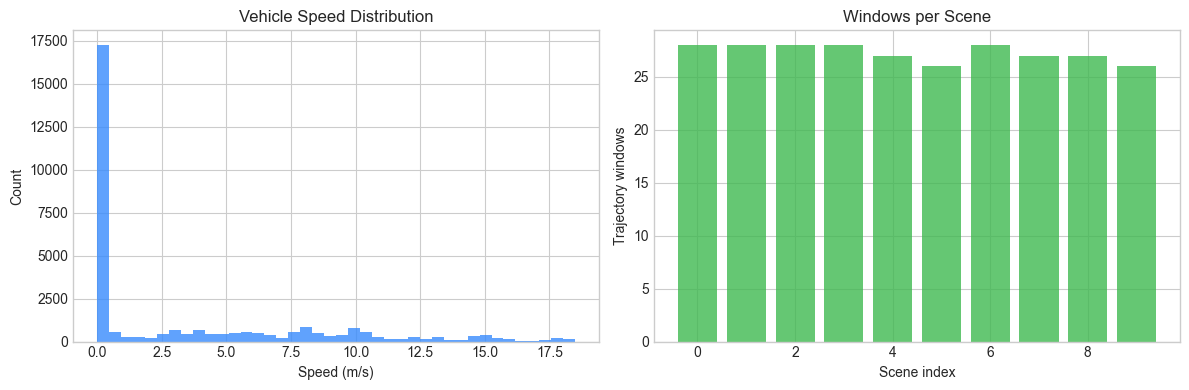

Saved: outputs/eda_stats.png


In [6]:
# Speed distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Velocity histogram
axes[0].hist(df['velocity'], bins=40, color='#388bfd', edgecolor='none', alpha=0.8)
axes[0].set_xlabel('Speed (m/s)')
axes[0].set_ylabel('Count')
axes[0].set_title('Vehicle Speed Distribution')

# Windows per scene
scene_counts = df.groupby('scene_token')['window_id'].nunique()
axes[1].bar(range(len(scene_counts)), scene_counts.values, color='#3fb950', alpha=0.8)
axes[1].set_xlabel('Scene index')
axes[1].set_ylabel('Trajectory windows')
axes[1].set_title('Windows per Scene')

plt.tight_layout()
plt.savefig('../outputs/eda_stats.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: outputs/eda_stats.png')

## 5 — Visualise raw trajectories on map tile

IndexError: too many indices for array: array is 0-dimensional, but 2 were indexed

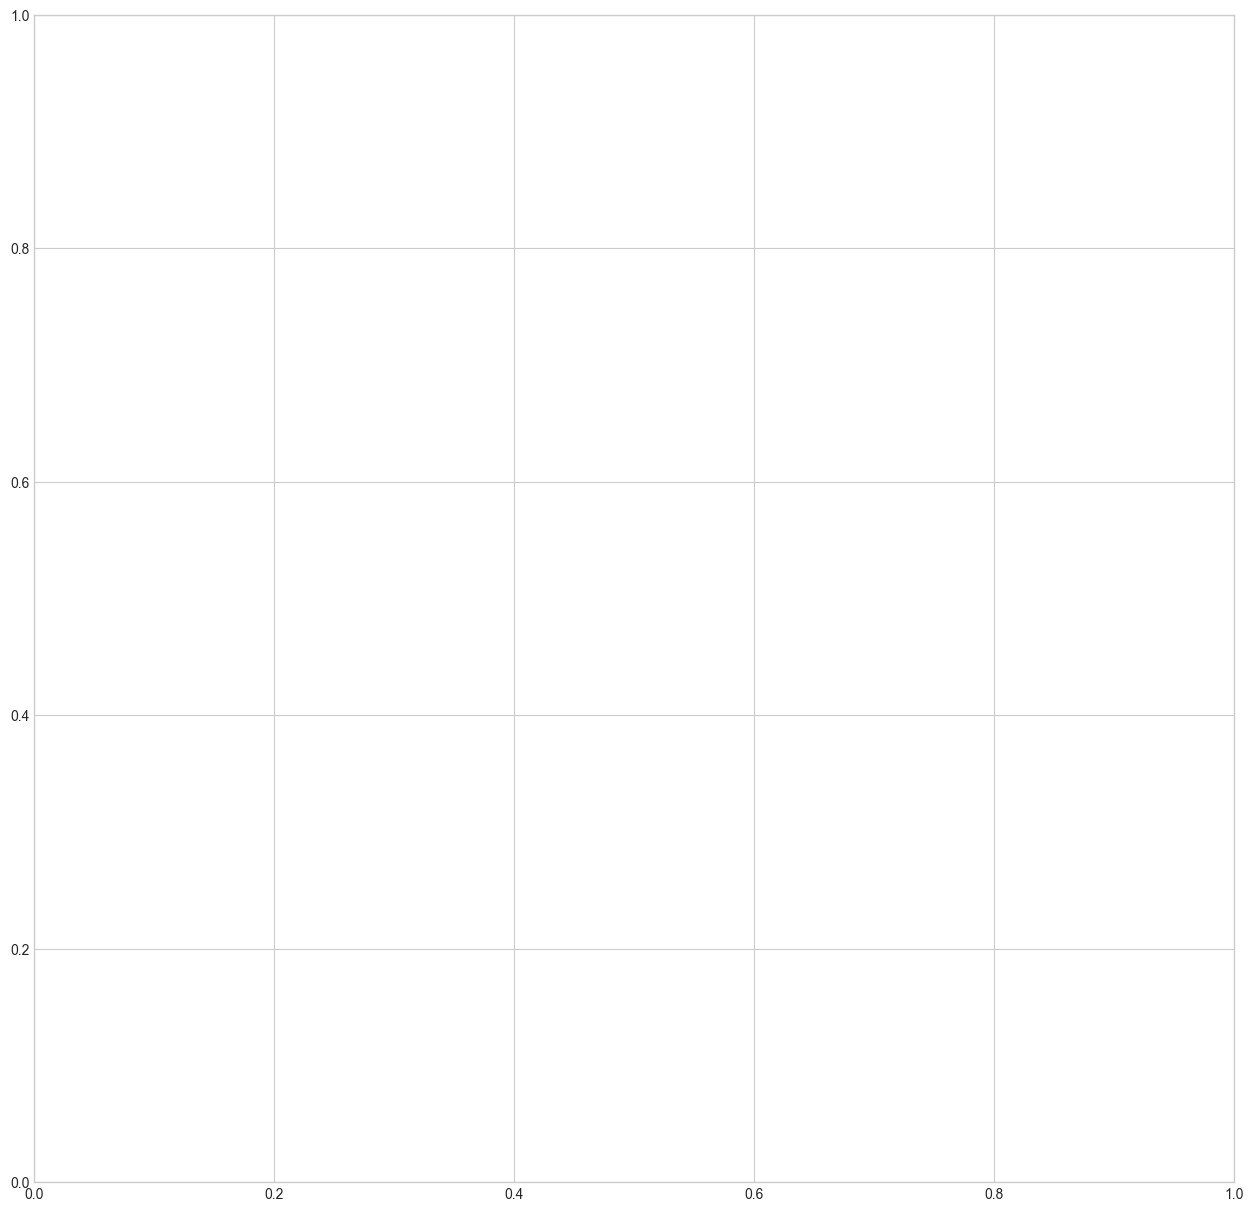

In [ ]:
from nuscenes.map_expansion.map_api import NuScenesMap
from nuscenes.map_expansion.bitmap import BitMap
import matplotlib.cm as cm

scene = nusc.scene[0]
scene_token = scene['token']
log = nusc.get('log', scene['log_token'])
map_name = log['location']

scene_df = df[(df['scene_token'] == scene_token) & (df['is_past'])]

x_min, x_max = scene_df['x'].min() - 20, scene_df['x'].max() + 20
y_min, y_max = scene_df['y'].min() - 20, scene_df['y'].max() + 20

nusc_map = NuScenesMap(dataroot='../data/nuscenes', map_name=map_name)
bitmap = BitMap('../data/nuscenes', map_name, 'basemap')

fig, ax = nusc_map.render_map_patch(
    (x_min, y_min, x_max, y_max),
    ['road_segment', 'lane', 'walkway'],
    figsize=(12, 12),
    render_egoposes_range=False,
    render_legend=True,
    bitmap=bitmap,
)

# Overlay vehicle tracks
instance_tokens = scene_df['instance_token'].unique()[:10]
colors = cm.tab10(np.linspace(0, 1, len(instance_tokens)))

for inst_token, color in zip(instance_tokens, colors):
    inst_df = scene_df[scene_df['instance_token'] == inst_token]
    first_window = inst_df['window_id'].min()
    track = inst_df[inst_df['window_id'] == first_window].sort_values('step')
    ax.plot(track['x'], track['y'], color=color, linewidth=2.5, alpha=0.9)
    ax.scatter(track['x'].iloc[-1], track['y'].iloc[-1],
               color=color, s=80, zorder=5)

ax.set_title(f'Vehicle tracks — {scene["name"]} ({map_name})', fontsize=12)
Path('../outputs').mkdir(exist_ok=True)
plt.savefig('../outputs/eda_map_tracks.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: outputs/eda_map_tracks.png')

## 6 — Verify agent-centric normalisation

In [ ]:
from dataset import TrajectoryDataset, PAST_STEPS, FUTURE_STEPS

# Load dataset (will print how many windows per split)
train_ds = TrajectoryDataset('../data/trajectories.parquet', split='train')
val_ds   = TrajectoryDataset('../data/trajectories.parquet', split='val')

# Inspect one normalised sample
past_seq, future_seq = train_ds[0]
print(f'past_seq  shape : {past_seq.shape}')    # (8, 4)
print(f'future_seq shape: {future_seq.shape}')  # (6, 2)

# After normalisation:
#   past_seq[-1, :2] should be very close to (0, 0) — the agent is at the origin
print(f'\nLast past position (should be ~0, 0): {past_seq[-1, :2].tolist()}')
print(f'Last past heading  (should be ~0.0) : {past_seq[-1, 2].item():.4f} rad')

In [ ]:
# Plot 5 normalised trajectories to confirm they all start at (0,0) facing right
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.suptitle('Normalised trajectories (all agents at origin, facing right → )', fontsize=11)

for i, ax in enumerate(axes):
    past, future = train_ds[i]
    past_xy   = past[:, :2].numpy()
    future_xy = future.numpy()

    ax.set_facecolor('#0d1117')
    ax.plot(past_xy[:, 0], past_xy[:, 1], color='#8b949e', lw=2, label='Past')
    ax.plot(future_xy[:, 0], future_xy[:, 1], color='#3fb950', lw=2, label='Future GT')
    ax.scatter(0, 0, color='white', s=60, zorder=5)  # current position
    ax.set_title(f'Sample {i}', color='#c9d1d9', fontsize=8)
    ax.tick_params(colors='#484f58', labelsize=7)
    ax.set_aspect('equal')
    ax.grid(True, color='#161b22', lw=0.5)
    if i == 0:
        ax.legend(fontsize=7, labelcolor='white', facecolor='#161b22', edgecolor='#21262d')

plt.tight_layout()
plt.savefig('../outputs/eda_normalised_samples.png', dpi=120, bbox_inches='tight')
plt.show()
print('Checkpoint: all agents should appear near (0,0) with past coming from the left.')

## Saturday 1 checkpoint ✓
If the map tile shows vehicle tracks and the normalised plot shows agents near the origin, Saturday 1 is **done**.

Next: `git add -A && git commit -m 'Saturday 1: EDA notebook and trajectory extraction'`